In [1]:
import numpy as np
from itertools import cycle
import os

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import datetime as dt
import subprocess
from scipy.ndimage import binary_fill_holes
from importlib import reload
#! ADD DEV VERSIONS OF RMOM6
import sys
sys.path.insert(0, '/g/data/gb02/ab8992/regional-mom6/regional-mom6')
sys.path.insert(0, '/g/data/gb02/ab8992/regional-mom6/mom6_forge')
from pathlib import Path
import regional_mom6 as rm
# from dask.distributed import Client
# client = Client()
# client

# Use restarts from 20th degree runs to setup 40th initial condition

In [2]:

## Choose your coordinates and the name of your experiment
yextent = [-56,-26]
xextent = [142,180]
expt_name = "full-40"
source_expt_name = "full-20"
# 
daterange = ["2011-06-25 00:00:00", "2020-12-31 00:00:00"] # This matches restart number 35 of 20th degree

## Place where all your input files go
inputdir = f"/g/data/nm03/ab8992/ttide-inputs/reruns/{expt_name}/"

## Directory where you'll run the experiment from
rundir = inputdir + "/tmp"
tmpdir = Path(f"/g/data/nm03/ab8992/glorys-download/tenyears")
# tmpdir = f"/home/149/ab8992/tasman-tides/rundirs/full-20/inputdir/forcing"
# tmpdir = "/home/149/ab8992/tasman-tides/rundirs/mkic/archive/output000/"
## Directory where fre tools are stored
toolpath = "/g/data/ik11/mom6_tools/tools/bin/" ## Compiled tools needed for construction of mask tables
for i in [rundir,inputdir]:
    if not os.path.exists(i):
        subprocess.run(f"mkdir {i} -p",shell=True)

In [3]:
expt = rm.experiment(
    longitude_extent = xextent,
    latitude_extent = yextent,
    date_range = daterange,
    hgrid_type = "even_spacing",
    resolution = 0.025,  ## Resolution
    number_vertical_layers = 100,      ## #zlayers
    layer_thickness_ratio = 20,       ## dz ratio
    depth = 5500,    ## Max depth of ocean
    mom_run_dir = rundir,
    tidal_constituents = ["M2"],
    mom_input_dir = inputdir,
    boundaries=["north", "south", "east", "west"],
    # fms_path = toolpath
)

This means that some areas may only have one or two layers between the surface and sea floor. 
For increased stability, consider increasing the minimum depth, or adjusting the vertical coordinate to add more layers near the surface.


## Multiply restart file by the ocean mask
Got to remove the weird stuff going on inside the restart file! Replace it with nans and then interpolate it the normal way

In [18]:
mask = xr.open_mfdataset(f"/g/data/nm03/ab8992/ttide-inputs/reruns/{source_expt_name}/topog.nc").mask.isel(ntiles = 0)
restart = xr.open_mfdataset(f"/g/data/nm03/ab8992/ttide-inputs/reruns/restarts/restart-{source_expt_name}_35/MOM.res.nc",decode_times=False)

varnames = {
     "time":"Time",
     "yq":"latq",
     "xq":"lonq",
     "yh":"lath",
     "xh":"lonh",
     "zl":"Layer",
     "eta":"sfc",
     "u":"u",
     "v":"v",
     "tracers":{"salt":"Salt","temp":"Temp"}
     }



mask = mask.where(mask>0)

restart_masked = xr.Dataset(
    data_vars = dict(
        Temp = (["Layer","yh","xh"],restart.Temp.rename({"lonh":"xh","lath":"yh"}).isel(Time = 0).values),
        Salt = (["Layer","yh","xh"],restart.Salt.rename({"lonh":"xh","lath":"yh"}).isel(Time = 0).values),
        u = (["Layer","yh","xh"],restart.u.interp(lonq = restart.lonh).rename({"lonq":"xh","lath":"yh"}).isel(Time = 0).values),
        v = (["Layer","yh","xh"],restart.v.interp(latq = restart.lath).rename({"lonh":"xh","latq":"yh"}).isel(Time = 0).values),
        sfc = (["yh","xh"],restart.sfc.rename({"lonh":"xh","lath":"yh"}).isel(Time = 0).values),
),
    coords = dict(
        Layer = restart.Layer.values,
        xh = restart.lonh.values,
        yh = restart.lath.values
    )
)

# Multiply each variable in restart by the mask
for var in restart_masked.data_vars.keys():
    restart_masked[var] = restart_masked[var]*mask.values
restart_masked.to_netcdf(f"/g/data/nm03/ab8992/ttide-inputs/reruns/restarts/restart-{source_expt_name}_35/MOM.res.masked.nc")

# mask.plot()

In [ ]:
ocean_varnames = {"time": "Time",
                  "yh": "yh",
                  "xh": "xh",
                  "zl": "Layer",
                  "eta": "sfc",
                  "u": "u",
                  "v": "v",
                  "tracers": {"salt": "Salt", "temp": "Temp"}
                  }
# Set up the initial condition.
expt.setup_initial_condition(
    f"/g/data/nm03/ab8992/ttide-inputs/reruns/restarts/restart-{source_expt_name}_35/MOM.res.masked.nc",
    ocean_varnames,
    arakawa_grid = "A"
    )

Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid


INFO:regional_mom6.regridding:Getting t points..
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Creating Regridder


Setting up Initial Conditions
Regridding Velocities... 

INFO:regional_mom6.rotation:Getting rotation angle
INFO:regional_mom6.rotation:Calculating grid rotation angle
INFO:regional_mom6.regridding:Getting u points..
INFO:regional_mom6.regridding:Getting v points..


Done.
Regridding Tracers... Done.
Regridding Free surface... Done.
Saving outputs... 

INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points


Processing north boundary velocity & tracers...Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid


KeyError: "No variable named 'Layer'. Variables on the dataset include ['so', 'thetao', 'vo', 'zos', 'uo', 'depth', 'latitude', 'time', 'longitude']"

In [5]:
# Set up the four boundary conditions.
ocean_varnames = {"time": "time",
                  "yh": "latitude",
                  "xh": "longitude",
                  "zl": "depth",
                  "eta": "zos",
                  "u": "uo",
                  "v": "vo",
                  "tracers": {"salt": "so", "temp": "thetao"}
                  }
expt.setup_ocean_state_boundaries(
    Path(tmpdir),
    ocean_varnames,
    arakawa_grid = "A"
    )

INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.utils:Units for depth did not need to be converted
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.rotation:Getting rotation angle


Processing north boundary velocity & tracers...Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid


INFO:regional_mom6.rotation:Calculating grid rotation angle
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding time dimension
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in salt_segment_001
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to salt_segment_001
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in temp_segment_001
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to temp_segment_001
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in u_segment_001
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to u_segment_001
INFO:regional_mom6.regridding:Renaming v

Done.
Processing south boundary velocity & tracers...Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid


INFO:regional_mom6.rotation:Getting rotation angle
INFO:regional_mom6.rotation:Calculating grid rotation angle
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding time dimension
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in salt_segment_002
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to salt_segment_002
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in temp_segment_002
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to temp_segment_002
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in u_segment_002
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to u_s

Done.
Processing east boundary velocity & tracers...Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid


INFO:regional_mom6.rotation:Getting rotation angle
INFO:regional_mom6.rotation:Calculating grid rotation angle
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding time dimension
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in salt_segment_003
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to salt_segment_003
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in temp_segment_003
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to temp_segment_003
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in u_segment_003
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to u_s

Done.
Processing west boundary velocity & tracers...Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid


INFO:regional_mom6.rotation:Getting rotation angle
INFO:regional_mom6.rotation:Calculating grid rotation angle
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding time dimension
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in salt_segment_004
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to salt_segment_004
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in temp_segment_004
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to temp_segment_004
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in u_segment_004
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to u_s

Done.


Setting up bathymetry...if this fails, please follow the printed instructions with your experiment topo object, like this: [experiment_obj].topo. For example, if the output tells you to run mpi_set_from_dataset instead of set_from_dataset. You would do: [experiment_obj].topo.mpi_set_from_dataset(...)
**NOTE**
            If bathymetry setup fails (e.g. kernel crashes), restart the kernel and edit this cell.
            Call ``[topo_object_name].mpi_set_from_dataset()`` instead. Follow the given instructions for using mpi
            and ESMF_Regrid outside of a python environment. This breaks up the process, so be sure to call
            ``[topo_object_name].tidy_dataset() after regridding with mpi.
Begin regridding dataset...

Original dataset size: 557.24 Mb
Regridded size: 58.00 Mb

Tidy bathymetry: Reading in regridded bathymetry to fix up metadata...done. Filling in inland lakes and channels... 

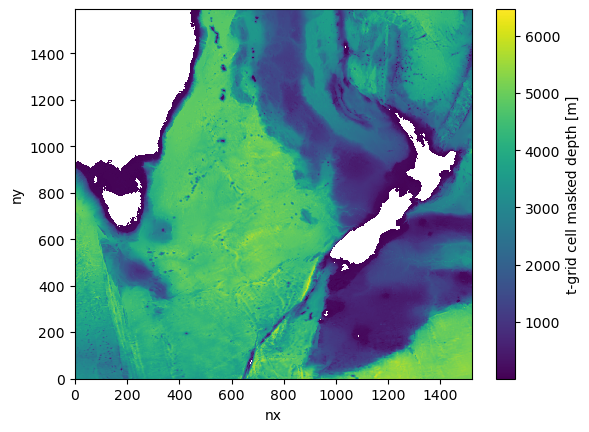

In [11]:
expt.setup_bathymetry(
    bathymetry_path='/g/data/nm03/ab8992/synbath2/SYNBATH_V1.2.nc',
    longitude_coordinate_name='lon',
    latitude_coordinate_name='lat',
    vertical_coordinate_name='z',
    )
expt.bathymetry.depth.where(expt.bathymetry.depth != 0).plot() #TODO add 0 as fill value in rmom6 so that it plots nicely without this ugly step

In [ ]:
# Save these again to fill in rim area


ic_tracers = xr.open_mfdataset(f"/g/data/nm03/ab8992/ttide-inputs/reruns/{expt_name}/init_tracers.nc")
ic_vels = xr.open_mfdataset(f"/g/data/nm03/ab8992/ttide-inputs/reruns/{expt_name}/init_vel.nc")
ic_eta = xr.open_mfdataset(f"/g/data/nm03/ab8992/ttide-inputs/reruns/{expt_name}/init_eta.nc")


for var in ["temp","salt"]:
    ic_tracers[var].loc[{"nx":ic_tracers.nx[0]}] = ic_tracers[var].isel(nx = 1)
    ic_tracers[var].loc[{"ny":ic_tracers.ny[0]}] = ic_tracers[var].isel(ny = 1)
    ic_tracers[var].loc[{"nx":ic_tracers.nx[-1]}] = ic_tracers[var].isel(nx = -2)
    ic_tracers[var].loc[{"ny":ic_tracers.ny[-1]}] = ic_tracers[var].isel(ny = -2)

ic_tracers.to_netcdf(f"/g/data/nm03/ab8992/ttide-inputs/reruns/{expt_name}/init_tracers_filled.nc")
ic_tracers.close()
var = "u"
ic_vels[var].loc[{"nxp":ic_vels.nxp[0]}] = ic_vels[var].isel(nxp = 1)
ic_vels[var].loc[{"ny":ic_vels.ny[0]}] = ic_vels[var].isel(ny = 1)
ic_vels[var].loc[{"nxp":ic_vels.nxp[-1]}] = ic_vels[var].isel(nxp = -2)
ic_vels[var].loc[{"ny":ic_vels.ny[-1]}] = ic_vels[var].isel(ny = -2)

var = "v"
ic_vels[var].loc[{"nx":ic_vels.nx[0]}] = ic_vels[var].isel(nx = 1)
ic_vels[var].loc[{"nyp":ic_vels.nyp[0]}] = ic_vels[var].isel(nyp = 1)
ic_vels[var].loc[{"nx":ic_vels.nx[-1]}] = ic_vels[var].isel(nx = -2)
ic_vels[var].loc[{"nyp":ic_vels.nyp[-1]}] = ic_vels[var].isel(nyp = -2)
ic_vels.to_netcdf(f"/g/data/nm03/ab8992/ttide-inputs/reruns/{expt_name}/init_vel_filled.nc")

ic_eta.eta_t.loc[{"nx":ic_eta.nx[0]}] = ic_eta.eta_t.isel(nx = 1)
ic_eta.eta_t.loc[{"ny":ic_eta.ny[0]}] = ic_eta.eta_t.isel(ny = 1)
ic_eta.eta_t.loc[{"nx":ic_eta.nx[-1]}] = ic_eta.eta_t.isel(nx = -2)
ic_eta.eta_t.loc[{"ny":ic_eta.ny[-1]}] = ic_eta.eta_t.isel(ny = -2)
ic_eta.to_netcdf(f"/g/data/nm03/ab8992/ttide-inputs/reruns/{expt_name}/init_eta_filled.nc")


In [7]:
expt.FRE_tools((40,40))


NOTE from make_solo_mosaic: there are 0 contacts (align-contact)
congradulation: You have successfully run make_solo_mosaic
MAKE SOLO MOSAIC

CompletedProcess(args='/home/157/ahg157/repos/mom5/src/tools/make_solo_mosaic/make_solo_mosaic --num_tiles 1 --dir . --mosaic_name ocean_mosaic --tile_file hgrid.nc', returncode=0)


cp: './ocean_mosaic.nc' and 'ocean_mosaic.nc' are the same file
cp: './hgrid.nc' and 'hgrid.nc' are the same file


cp ./hgrid.nc hgrid.nc 

NOTE from make_coupler_mosaic: the ocean land/sea mask will be determined by field depth from file topog.nc
mosaic_file is grid_spec.nc

***** Congratulation! You have successfully run make_quick_mosaic
QUICK MOSAIC

CompletedProcess(args='/home/157/ahg157/repos/mom5/src/tools/make_quick_mosaic/make_quick_mosaic --input_mosaic ocean_mosaic.nc --mosaic_name grid_spec --ocean_topog topog.nc', returncode=0)

 ===>NOTE from check_mask: when layout is specified, min_pe and max_pe is set to layout(1)*layout(2)=1600

 ===>NOTE from check_mask: Below is the list of command line arguments.

grid_file = ocean_mosaic.nc
topog_file = topog.nc
min_pe = 1600
max_pe = 1600
layout = 40, 40
halo = 4
sea_level = 0
show_valid_only is not set
nobc = 0

 ===>NOTE from check_mask: End of command line arguments.

 ===>NOTE from check_mask: the grid file is version 2 (mosaic grid) grid which contains field gridfiles

==>NOTE from get_boundary_type: x_boundary_type is solid_walls

==>N

In [8]:
expt.setup_run_directory("",using_payu=True)

Number of CPUs required:  1435


## Add Tides to an Existing Run
Offline I've copied all the inputs from the ttide-20 run. All that this notebook does is use the out-of-the-box NWA scripts to add tidal constituents. I'll then need to go back to the MOM_input file from my old tide test to rectify the new one 

In [4]:
import os
import xarray as xr
os.chdir("/home/149/ab8992/cosima_regional/development/withtides/regional-mom6/")
os.listdir()
import boundary_tides as bt

In [8]:
## VERBATIM COPY OLD CODE AND SEE WHAT HAPPENS

# """
# constituents in TPXO9:
# con =
# "m2  ",  0
# "s2  ",  1
# "n2  ",  2
# "k2  ",  3
# "k1  ",  4
# "o1  ",  5
# "p1  ",  6
# "q1  ",  7
# "mm  ",  8
# "mf  ",  9
# "m4  ", 10
# "mn4 ", 11
# "ms4 ", 12
# "2n2 ", 13
# "s1  "  14
# """
# Use these constituents:
# (MOM6 does not currently support m4, mn4, ms4, 2n2, or s1.)
# constituents = range(0, 10)

constituents = [0]

# Hardcoded for my ttide domain!!! 

horizontal_subset = dict(ny=slice(200,380), nx=slice(850,1100))

# Path to tpxo9.v1 data
tpxo_dir = '/g/data/nm03/TPXO'

# Save output here
output_dir = inputdir + "/forcing"

# Setup NWA boundaries
hgrid = xr.open_dataset(inputdir + '/hgrid.nc')
# segments taken from nwa25_obc.py
segments = [
    bt.Segment(1, 'south', hgrid, output_dir=output_dir),
    bt.Segment(2, 'north', hgrid, output_dir=output_dir),
    bt.Segment(3, 'west', hgrid, output_dir=output_dir),
    bt.Segment(4, 'east', hgrid, output_dir=output_dir)
]
# reload(bt)
bt.write_tpxo(constituents, tpxo_dir, segments, horizontal_subset,"tpxo9.v1.nc")

## Regrid era


In [9]:
expt.daterange[0].year

2015

In [12]:
ls /g/data/

hh5/  nm03/  v45/  x77/
